In [48]:
import uproot
import awkward as ak
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from tqdm.notebook import tqdm
import seaborn as sns
from collections import Counter

In [60]:
filepath = "data/output_1000_seq3.root"
data = uproot.open(filepath + ":L1BMTFStubSequences").arrays()
df = ak.to_dataframe(data)
df.head()

nL1BMTFStub  L1BMTFStub_hwQual  L1BMTFStub_hwPhi  \
entry subentry                                                     
0     0                   1                  4               674   
1     0                   1                  2              -278   
2     0                   2                  5               674   
      1                   2                  6             -1092   
3     0                   3                  6               861   

                L1BMTFStub_hwPhiB  L1BMTFStub_hwEta  L1BMTFStub_hwQEta  \
entry subentry                                                           
0     0                       282                 0                  0   
1     0                        87                 0                  0   
2     0                       279                32                 32   
      1                       163                16                  0   
3     0                       220                16                  0   

                L1BMTFStub_wheel  L1BMTFStub_sector  L1BMTFStub_station  \
entry subentry                                                            
0     0                       -1                  8                   1   
1     0                        1                  9                   1   
2     0                       -1                  8                   1   
      1                       -1                  9                   2   
3     0                       -1                  2                   1   

                orbitNumber  bunchCrossing  sequenceIndex  
entry subentry                                             
0     0           261881864            986              0  
1     0           261881864            987              0  
2     0           261881864            988              0  
      1           261881864            988              0  
3     0           261881864           1164              1

In [59]:
dfgb = df.groupby("sequenceIndex")

index = 45
print(f"Sequence: {index}")

dfg = dfgb.get_group(index)
for sector, dfsector in dfg.groupby("L1BMTFStub_sector"):
    print(f'\tSector: {sector}, Wheel: {dfsector["L1BMTFStub_wheel"].values}, Station: {dfsector["L1BMTFStub_station"].values}, BX: {dfsector["bunchCrossing"].values}')

Sequence: 45
	Sector: 1, Wheel: [0 0 0], Station: [1 1 2], BX: [2606 2607 2607]
	Sector: 2, Wheel: [-1], Station: [3], BX: [2607]
	Sector: 5, Wheel: [1], Station: [1], BX: [2605]


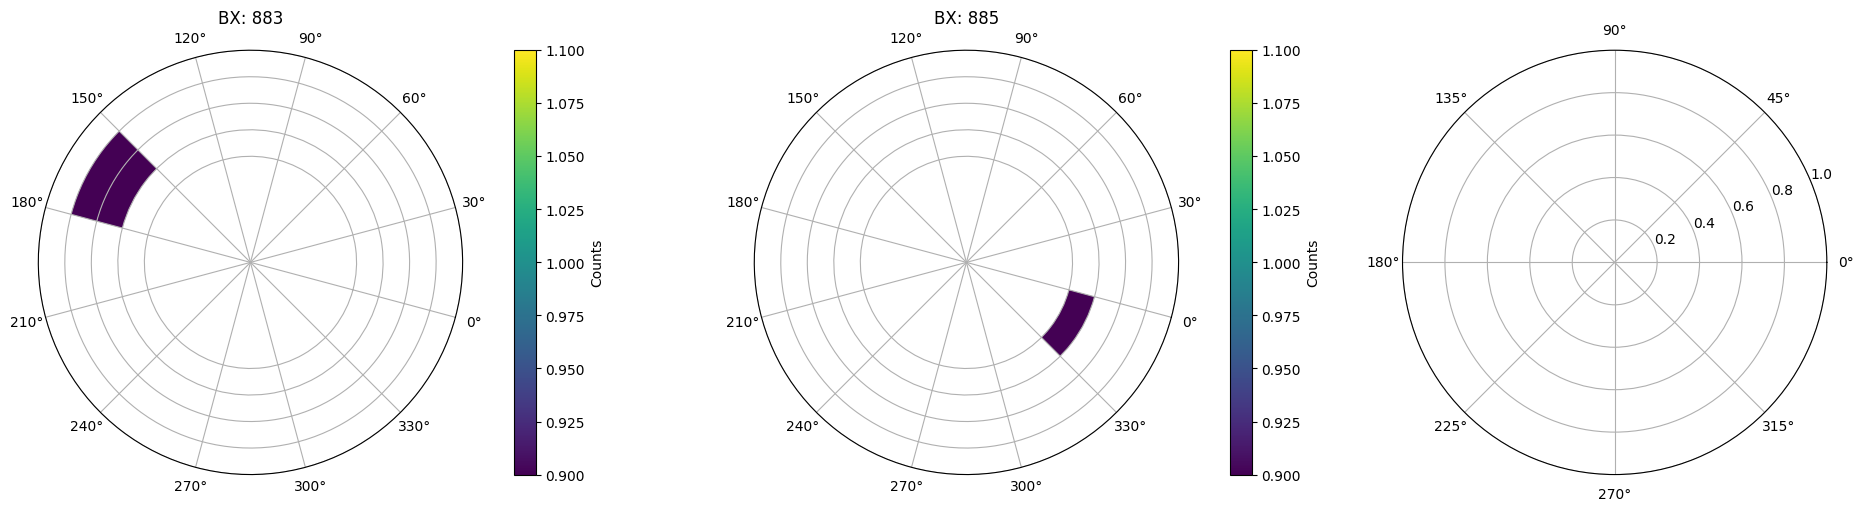

In [4]:
df_grouped = df.groupby("sequenceIndex")
index = 102

dfs = df_grouped.get_group(index)
dfs_grouped = dfs.groupby("L1BMTFStub_wheel")

wheel = 1
dfsw = dfs_grouped.get_group(wheel)

fig, axs = plt.subplots(1, 3, figsize=(20, 5), subplot_kw={"projection": "polar"}, layout="constrained")

for ii, (bx, dfswb) in enumerate(dfsw.groupby("bunchCrossing")):
    axs[ii].set_title(f"BX: {bx}")
    axs[ii].set_thetagrids(range(0, 360, 30))
    axs[ii].set_theta_zero_location("E", -15)
    axs[ii].set_rlim(0, 2)
    axs[ii].set_yticklabels([])
    axs[ii].set_rgrids((0, 1, 1.25, 1.5, 1.75, 2))

    station_counts = {}
    for sector, station in zip(dfswb["L1BMTFStub_sector"].values, dfswb["L1BMTFStub_station"].values):
        sector = sector.item()
        station = station.item()

        if (sector, station) in station_counts:
            station_counts[(sector, station)] += 1

        else:
            station_counts[(sector, station)] = 1

    cmap_fill = cm.viridis
    norm_fill = Normalize(vmin=min(station_counts.values()), vmax=max(station_counts.values()))

    for key in station_counts:
        sector, station = key
        counts = station_counts[key]

        axs[ii].bar(
            x=sector * np.pi/6 + np.pi/12, 
            bottom=1.0 + (station - 1) * 0.25, 
            height=0.25,
            width=np.pi/6, 
            color=cmap_fill(norm_fill(counts))
        )

    sm = cm.ScalarMappable(cmap=cmap_fill, norm=norm_fill)
    sm.set_array([])
    plt.colorbar(sm, ax=axs[ii], orientation="vertical", label="Counts");

In [ ]:
def getSameBxTargetCollections(bxs):
    target_pairs = [
        [(bx, station) for station in range(1, 4)] for bx in bxs
    ]

    target_pairs += [
        [(bx, station) for station in range(2, 5)] for bx in bxs
    ]

    return target_pairs

def getMultiBxTargetCollections(bxs):
    target_pairs = [
        [(bx, station) for bx, station in zip(bxs, range(1, 4))]
    ]

    target_pairs += [
        [(bx, station) for bx, station in zip(bxs, range(2, 5))]
    ]

    return target_pairs

In [ ]:
same_bx_selection = {}
multi_bx_selection = {}

for idx_seq, df_seq in tqdm(df.groupby("sequenceIndex")):
    # df_seq_grouped = df_seq.groupby(["bunchCrossing", "L1BMTFStub_station"])
    pairs = [
        tuple(el.item() for el in key) 
        for key in df_seq.groupby(["bunchCrossing", "L1BMTFStub_station"]).indices
    ]
    
    same_bx_collections = getSameBxTargetCollections(df_seq["bunchCrossing"].unique().tolist())

    for tps in same_bx_collections:
        if np.all([target_pair in pairs for target_pair in tps]):
            """
            Here we keep only the entries of the sequence sub-dataframe that 
            correspond to the identified (bx, station) pairs.
            This allows us then to groupby wheel and keep only the wheels that are
            at most distant 1 to one another.
            """
            mi = pd.MultiIndex.from_tuples(tps, names=["bunchCrossing", "L1BMTFStub_station"])
            df_temp = df_seq[
                df_seq.set_index(["bunchCrossing", "L1BMTFStub_station"]).index.isin(mi)
            ]


            
            # wheels = sorted([w.item() for w in df_temp.groupby("L1BMTFStub_wheel").indices])
            


            # wheels = []

            # for target_pair in tps:
            #     df_group = df_seq_grouped.get_group(target_pair)
            #     wheels.append(df_group["L1BMTFStub_wheel"].unique().tolist())

            # wheel_check_passed, good_wheels = wheelCheck(wheels)

            # if wheel_check_passed:
            #     wheel_mask = np.isin()

            #     if idx_seq in same_bx_selection:
            #         same_bx_selection[idx_seq] += [tps]

            #     else:
            #         same_bx_selection[idx_seq] = [tps]

    # multi_bx_collections = getMultiBxTargetCollections(df_seq["bunchCrossing"].unique().tolist())

    # for tps in multi_bx_collections:
    #     if np.all([target_pair in pairs for target_pair in tps]):
    #         wheels = []

    #         for target_pair in tps:
    #             df_group = df_seq_grouped.get_group(target_pair)
    #             wheels.append(df_group["L1BMTFStub_wheel"].unique().tolist())

    #         if wheelCheck(wheels):
    #             if idx_seq in multi_bx_selection:
    #                 multi_bx_selection[idx_seq] += [tps]

    #             else:
    #                 multi_bx_selection[idx_seq] = [tps]

  0%|          | 0/52973 [00:00<?, ?it/s]

In [47]:
a = [1, 2, 3]
b = a.copy()
b.pop(0)
b
a

[1, 2, 3]

In [35]:
same_bx_collections[0]

[(2822, 1), (2822, 2), (2822, 3)]

In [26]:
df_example = sns.load_dataset("planets")
df_example.head()

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


In [28]:
df_example.tail()

,method,number,orbital_period,mass,distance,year
1030,Transit,1,3.941507,NaN,172.0,2006
1031,Transit,1,2.615864,NaN,148.0,2007
1032,Transit,1,3.191524,NaN,174.0,2007
1033,Transit,1,4.125083,NaN,293.0,2008
1034,Transit,1,4.187757,NaN,260.0,2008


In [29]:
pairs = [("Radial Velocity", 2006), ("Radial Velocity", 2011)]          # your allowed couples
colA, colB = "method", "year"   # the two columns to match

mi = pd.MultiIndex.from_tuples(pairs, names=[colA, colB])
mi

MultiIndex([('Radial Velocity', 2006),
            ('Radial Velocity', 2011)],
           names=['method', 'year'])

In [37]:
df_out = df_example[df_example.set_index([colA, colB]).index.isin(mi)]

In [38]:
df_out

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.30000,7.100,77.40,2006
2,Radial Velocity,1,763.00000,2.600,19.84,2011
20,Radial Velocity,5,0.73654,NaN,12.53,2011
50,Radial Velocity,1,594.90000,7.600,47.53,2006
88,Radial Velocity,1,392.60000,0.910,NaN,2011
...,...,...,...,...,...,...
625,Radial Velocity,2,9017.80000,NaN,44.80,2011
629,Radial Velocity,3,147.73000,1.280,52.88,2006
632,Radial Velocity,3,8.13520,0.036,25.87,2011
633,Radial Velocity,3,32.03000,0.410,25.87,2011
